
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

## Solución

Como sólo nos interesa la solución radial, tomaremos que la parte radial del laplaciano es igual a cero. Así,

$$
\begin{align*}
-\dfrac{\hbar^2}{2m} \dfrac{1}{r^2} \dfrac{\partial}{\partial r} \left( r^2 \dfrac{\partial \psi(\vec{r})}{\partial r} \right) 
-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r}) &= \\
-\dfrac{\hbar^2}{2m} \left(\dfrac{\partial^2 \psi(\vec{r})}{\partial r^2} + \dfrac{2}{r} \dfrac{\partial \psi(\vec{r})}{\partial r} \right)
-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r}) &=  E\,\psi(\vec{r})
\end{align*}
$$

Al haber solo una variable, cambiemos $\vec{r}$ por $x$ y las derivadas parciales por totales:
$$
-\dfrac{\hbar^2}{2m} \left(\dfrac{d^2 \psi(x)}{d x^2} + \dfrac{2}{x} \dfrac{d \psi(x)}{d x} \right)
-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{x}\psi(x) =  E\,\psi(x)
$$

No voy a escribir el desarrollo pues la verdad me da mucho tedio escribir $\LaTeX$, pero al hacer la sustitución $\psi(x) = u(x) / x$ se elimina la primera derivada, haciendo que la ecuación resulte en:
$$
-\dfrac{\hbar^2}{2m} \dfrac{d^2 u(x)}{d x^2}
-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{x} u(x) =  E\, u(x)
$$

Ahora, supongamos una diferencia $\Delta x$ pequeña y aproximemos la segunda derivada:

$$
-\dfrac{\hbar^2}{2m} \dfrac{u(x + \Delta x) + u(x - \Delta x) - 2 u(x)}{(\Delta x)^2} 
-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{x} u(x) =  E\, u(x)
$$

Si $k =\dfrac{2m(\Delta x)^2}{\hbar^2}$, $u(x)= u_i$, $U(x)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{x} = U_i$ entonces

$$-\dfrac{1}{k} u_{i-1}
\dfrac{1}{k}\bigg(2 + k\,U_i\bigg) u_i
-\dfrac{1}{k} u_{i+1}
\approx E\, u_i
$$


Está claro que para $x = 0$ la densidad de probabilidad debe de anularse. Como trabajaré en [unidades atómicas](https://en.wikipedia.org/wiki/Atomic_units), las medidas en $x$ estarán dadas en radios de Bohr, por lo que si tomamos $x = 30 n^2$ como cota superior donde la densidad de probabilidad debe anularse, no estaremos anulando incorrectamente parte de la función de onda. El $n^2$ lo pongo debido a que las densidades de probabilidad se hacen más anchas a medida que se aumenta el nivel de energía.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

In [2]:
rmin = 1e-5
rmax = 50
N = 1000

x = np.linspace(rmin, rmax, N)
dx = x[1] - x[0]
k = 2 * dx * dx

def FDM_Matrix(x, U, k):
    n = len(x)
    V = np.zeros((n, n))

    V[0, 0] = 2 + k * U(x[0])

    for i in range(1, n):
        V[i, i] = 2 + k * U(x[i])
        V[i - 1, i] = -1
        V[i, i - 1] = -1

    return V


# Como las unidades son atómicas, todo lo que acompaña al 1/x es igual a 1
U = lambda x: -1 / x

M = FDM_Matrix(x, U, k) / k
E, u = np.linalg.eigh(M) # eigh porque la matriz es simétrica
E_valid = E[E < 0]

E_valid

array([-9.96011979e+04, -4.99487490e-01, -1.24955436e-01, -5.55442739e-02,
       -3.12005948e-02, -1.78776812e-02, -2.31621876e-03])

Los estados ligados del átomo de hidrógeno siempre tienen energía negativa, y se van acercando poco a poco al cero [1]. Teniendo esto en cuenta, los resultados que den autovalores $E \gt 0$ no serán tomados en cuenta pues no tienen relevancia en este problema. En principio, si se tomara un `rmax` infinitamente grande, todos los autovalores darían números negativos; es el hecho de tener una cota superior en la distancia lo que hace que los resultados pierdan significancia física.

Por otra parte, nótese que el primer valor es gigantesco: esto es un artefacto numérico, y lo eliminaré para los siguientes pasos.

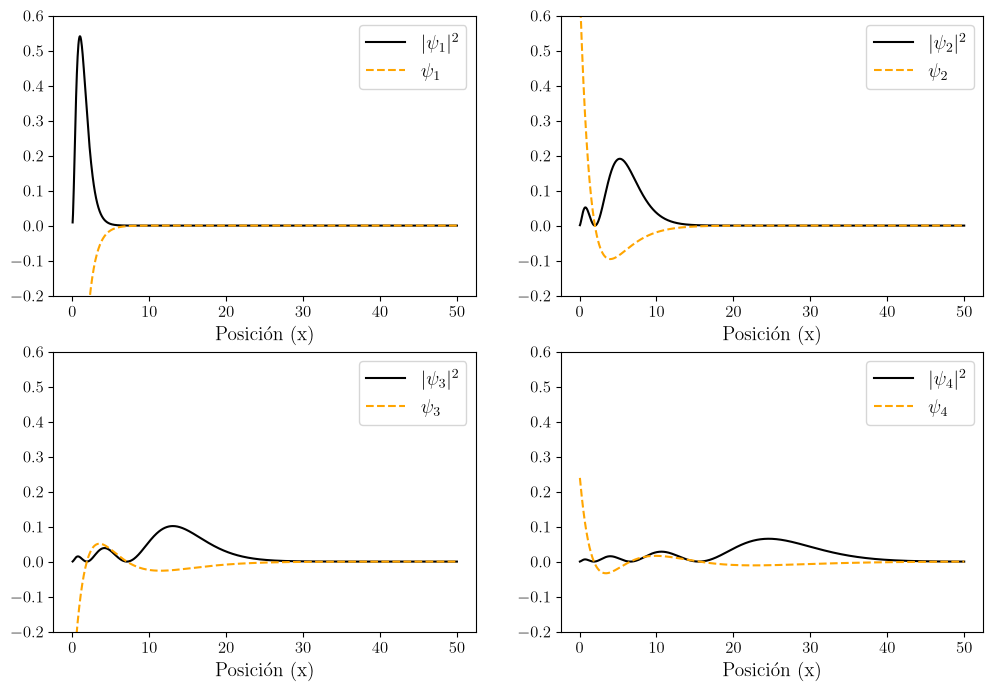

In [3]:
# Se descarta el primer valor ya que es impreciso
E_real = E_valid[1:]
u_real = u.T[E < 0][1:]

x_plot = x[1:]
psi = u_real[:, 1:] / x_plot

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs_flat = axs.flatten()

for i, ax in enumerate(axs_flat):
    # Integro u en vez de psi pues como es radial el jacobiano lleva un r^2, pero
    # como u = x psi => u^2 = x^2 psi^2, y ya tiene incluido el factor del jacobiano
    area = np.trapezoid(u_real[i, 1:]**2, x=x_plot)

    ax.plot(x_plot, u_real[i, 1:]**2 / area, label=f"$|\\psi_{i + 1}|^2$", color="black")
    ax.plot(x_plot, psi[i] / np.sqrt(area), "--", label=f"$\\psi_{i + 1}$", color="orange")
    ax.set_xlabel("Posición (x)")
    ax.set_ylim((-0.2, 0.6))
    ax.legend()

plt.show()


In [4]:
E0 = -13.6 # eV
print("Energías en unidades de eV, obtenidas numéricamente comparadas con las teóricas")
# Para la conversión de unidades, ver referencia 2
for i, E in enumerate(E_real):
    E_num = E * 27.211
    E_teo = E0 / ((i + 1)**2)
    print(f"E_{i + 1} (numérico) = {E_num:.3f} eV \t E_{i + 1} (teórico) = {E_teo:.3f} \t diff = {abs(E_num - E_teo)}")

Energías en unidades de eV, obtenidas numéricamente comparadas con las teóricas
E_1 (numérico) = -13.592 eV 	 E_1 (teórico) = -13.600 	 diff = 0.008445914262621201
E_2 (numérico) = -3.400 eV 	 E_2 (teórico) = -3.400 	 diff = 0.00016237858365197866
E_3 (numérico) = -1.511 eV 	 E_3 (teórico) = -1.511 	 diff = 0.00030412644709221226
E_4 (numérico) = -0.849 eV 	 E_4 (teórico) = -0.850 	 diff = 0.0010006154990606086
E_5 (numérico) = -0.486 eV 	 E_5 (teórico) = -0.544 	 diff = 0.057530416908578075
E_6 (numérico) = -0.063 eV 	 E_6 (teórico) = -0.378 	 diff = 0.3147511491071864


Las energías dan un muy buen resultado, sobre todo las primeras. Si se aumentara el parámetro `rmax` y el número de puntos del grid seguramente se lograría tener más energías y con cada vez mayor precisión. 

Por su parte, las funciones de onda, o por lo menos las densidades de probabilidad, se asemejan visualmente bastante a las que se mostraron en el notebook 2.3. No hice un chequeo formal ni exhaustivo, pero quedo contento con el resultado.

## Referencias

[1] https://farside.ph.utexas.edu/teaching/qm/Quantum/node44.html  
[2] https://es.wikipedia.org/wiki/Hartree